**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Luis Felipe García Domínguez

# Tarea 3: Regresión Lineal y Clasificación
## Dataset: Wine Quality (Red) - UCI

---

# 1. Preparación del entorno y librerías

Importamos las herramientas básicas para trabajar. En esta tarea, además de las librerías para manejo de tablas/datos (`numpy`, `pandas`), y generación de gráficas (`matplotlib`, `seaborn`), requerimos de `sklearn`, para ejecutar la regresión.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore", category=FutureWarning)

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", __import__("matplotlib").__version__)
print("scikit-learn", sklearn.__version__)

numpy        2.5.3
pandas       3.0.6
matplotlib   3.11.2
scikit-learn 1.9.1


Configuramos la paleta de colores y el estilo visual de los gráficos.

In [2]:
# Paleta de colores de la tarea
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_CLARO = "#BFD5EA"
ROJO = "#C0392B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

---

## 2. Carga de datos

El conjunto de datos proviene del repositorio de la Universidad de California en Irvine (UCI), publicado por Cortez et al. (2009). Registra 1,599 muestras de la variante tinta del vino portugués *"Vinho Verde"*. 
El objetivo es modelar la relación entre las propiedades químicas del vino y la calificación otorgada por jueces expertos mediante regresión lineal.
Cabe mencionar que el conjunto original consta de dos datasets, uno para el vino rojo y otro para el vino blanco. En esta tarea utilizaremos únicamente los datos del vino rojo (`winequality-red.csv`).
- **Fuente:** Cortez et al. (2009), *Modeling wine preferences by data mining from physicochemical properties*, Decision Support Systems.
- **Unidad de observación:** Una muestra de vino tinto (cada fila corresponde a una botella/prueba independiente).
- **Variables predictoras (11):** Mediciones fisicoquímicas objetivas de laboratorio (acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre y total, densidad, pH, sulfatos y alcohol).
- **Variable objetivo (`quality`):** Puntuación sensorial basada en la mediana de al menos tres catadores expertos. En teoría va de 0 (muy malo) a 10 (excelente); en este conjunto los valores observados van de 3 a 8.
- **Valores faltantes:** No contiene registros nulos, por lo que no requiere imputación inicial.

El dataset se encuentra en la carpeta `data/` de este repositorio. Procedemos con la carga local.

In [3]:
# Carga del dataset
ruta_datos = "../data/winequality-red.csv"
df = pd.read_csv(ruta_datos, sep=";")

print(f"{df.shape[0]} muestras × {df.shape[1]} columnas")
df.head()

1599 muestras × 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Diccionario de variables

Para entender qué representa cada columna en el análisis, resumimos los 12 atributos del dataset a continuación:

| Variable | Descripción | Unidad |
| :--- | :--- | :--- |
| `fixed acidity` | Acidez fija: ácidos no volátiles involucrados en el vino (principalmente ácido tartárico). | $\text{g/dm}^3$ |
| `volatile acidity` | Acidez volátil: cantidad de ácido acético; en concentraciones altas produce sabor agrio o avinagrado. | $\text{g/dm}^3$ |
| `citric acid` | Ácido cítrico: presente en bajas cantidades, aporta frescura y notas frutales. | $\text{g/dm}^3$ |
| `residual sugar` | Azúcar residual: cantidad de azúcar remanente después de finalizar la fermentación. | $\text{g/dm}^3$ |
| `chlorides` | Cloruros: contenido de sal en el vino (cloruro de sodio). | $\text{g/dm}^3$ |
| `free sulfur dioxide` | Dióxido de azufre libre: forma activa del $\text{SO}_2$ que previene el crecimiento bacteriano y la oxidación. | $\text{mg/dm}^3$ |
| `total sulfur dioxide` | Dióxido de azufre total: suma del $\text{SO}_2$ libre y ligado; en exceso se percibe en nariz y garganta. | $\text{mg/dm}^3$ |
| `density` | Densidad del vino: cercana a la del agua, varía en función del azúcar y del contenido alcohólico. | $\text{g/cm}^3$ |
| `pH` | Escala de acidez o alcalinidad (la mayoría de los vinos se sitúa entre 3.0 y 4.0). | Escala pH |
| `sulphates` | Sulfatos: aditivo mineral (sulfato de potasio) que contribuye a los niveles de $\text{SO}_2$ antimicrobiano y antioxidante. | $\text{g/dm}^3$ |
| `alcohol` | Graduación alcohólica: porcentaje de alcohol por volumen presente en la muestra. | % vol. |
| `quality` | Calidad sensorial: puntuación asignada por catadores expertos (mediana de al menos 3 evaluaciones). | Entero (0 a 10) |

En esta ocasión, como parte de las indicaciones de la tarea, ha sido definido que `quality` es nuestra variable objetivo, mientras que el resto de variables se consideran predictoras.

Exploramos los datos, comenzando por observar los rangos de la tabla, lo que también nos confirma que no tenemos faltantes.

In [4]:
# Rangos (mínimo, máximo) y verificación de valores faltantes
resumen = df.agg(["min", "max"]).T
resumen["faltantes"] = df.isna().sum()
resumen.round(2)

,min,max,faltantes
fixed acidity,4.60,15.90,0
volatile acidity,0.12,1.58,0
citric acid,0.00,1.00,0
residual sugar,0.90,15.50,0
chlorides,0.01,0.61,0
free sulfur dioxide,1.00,72.00,0
total sulfur dioxide,6.00,289.00,0
density,0.99,1.00,0
pH,2.74,4.01,0
sulphates,0.33,2.00,0


Obtenemos la matriz de correlación del dataset.

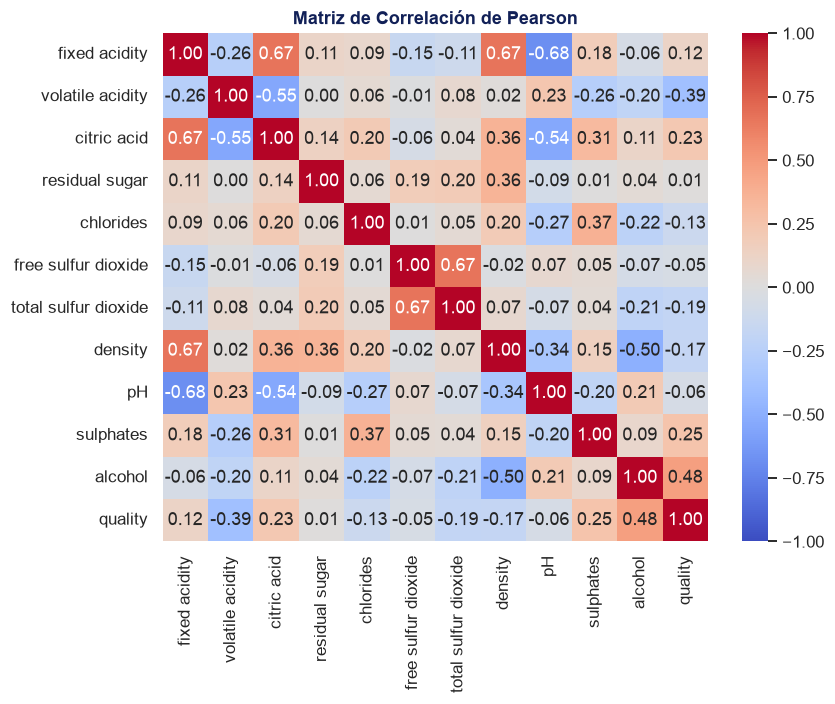

In [5]:
# Calculamos la matriz
matriz_pearson = df.corr(method='pearson')

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlación de Pearson')
plt.show()

**Lectura.** Observamos que la variable objetivo (`quality`) presenta mayor correlación positiva con `alcohol` ($r = 0.48$), mientras que tiene mayor correlación negativa con `volatile acidity` ($r = -0.39$). Por otra parte, presenta correlación casi nula con `residual sugar` ($r = 0.01$).

Esto nos dice que:

1. A mayor concentración de alcohol, los catadores tienden a otorgar mejores calificaciones al vino.
2. Un contenido alto de acidez volátil aporta sabores indeseables, lo que provoca que los catadores bajen la calificación.
3. El azúcar residual prácticamente no influye de forma lineal en la calificación.

Inspeccionamos la distribución de `quality`.

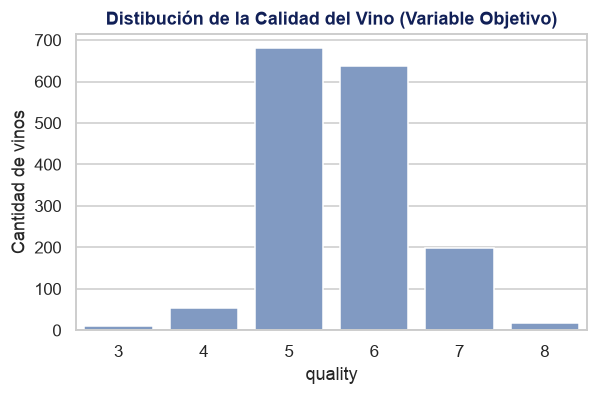

In [6]:
#Distrbución de la variable objetivo
plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x='quality', color=AZUL)
plt.title("Distibución de la Calidad del Vino (Variable Objetivo)")
plt.ylabel("Cantidad de vinos")
plt.show()

**Lectura.** La calidad de los vinos se concentra casi exclusivamente en valores intermedios. Observamos cómo los vinos con notas 5 y 6 (junto con el 7, en menor medida) abarcan más del 80% del conjunto. Los casos con calidades bajas o muy altas son menores, lo que refleja un (marcado) desbalance hacia vinos de calidad promedio.

---

## 3. Regresión lineal simple

Como ejercicio preliminar (siguiendo el flujo visto en clase), ajustamos primero un modelo univariado utilizando únicamente el nivel de `alcohol` que, como se vio en la sección anterior, fue la variable con mayor correlación con la calidad. 
Esto nos permite visualizar la recta en dos dimensiones, interpretar la pendiente y el intercepto, y contar con un modelo simple de referencia para contrastar más adelante frente a la regresión múltiple y el promedio, requeridos en la tarea.

In [7]:
x = df.alcohol.to_numpy()        # alcohol: la variable independiente
y_obs = df.quality.to_numpy()    # quality: la variable dependiente

# Obtenemos la pendiente e intercepto
theta1 = np.sum((x - x.mean()) * (y_obs - y_obs.mean())) / np.sum((x - x.mean()) ** 2)
theta0 = y_obs.mean() - theta1 * x.mean()

print(f"θ0 = {theta0:.2f}")
print(f"θ1 = {theta1:.3f}")

θ0 = 1.87
θ1 = 0.361


Podemos interpretar el resultado anterior como que, por cada grado de alcohol, `quality` sube en promedio $0.36$ puntos. Así mismo, el valor de partida de la recta ($θ_0 = 1.87$), nos da la predicción teórica de calidad para un vino con 0% de alcohol, que no es un valor imposible o sin sentido.

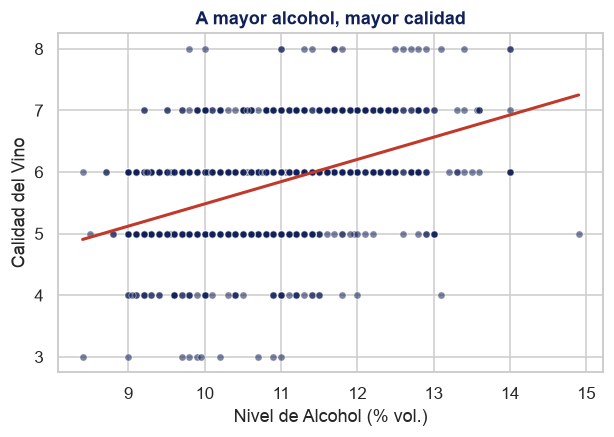

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4))

# Graficamos mediante un scatter plot
ax.scatter(x, y_obs, s=22, color=AZUL_OSCURO, alpha=0.55, edgecolor="white", linewidth=0.5)
malla = np.linspace(x.min(), x.max(), 100)
ax.plot(malla, theta0 + theta1 * malla, color=ROJO, linewidth=2)

# Etiquetas del gráfico
ax.set_xlabel("Nivel de Alcohol (% vol.)")
ax.set_ylabel("Calidad del Vino")
ax.set_title("A mayor alcohol, mayor calidad")
plt.show()

**Lectura.** La recta ajustada ($\hat{y} = 1.87 + 0.36 \cdot \text{alcohol}$) confirma la tendencia positiva: a mayor graduación alcohólica, los catadores tienden a calificar mejor el vino (subiendo en promedio 0.36 puntos por cada grado de alcohol). 

Dado que la calidad solo toma valores enteros (3 al 8), los puntos están distribuidos en filas horizontales paralelas. La recta pasa por el centro de la nube de puntos indicando la tendencia general, aunque con una dispersión considerable.

Contrastamos los resultados utilizando scikit-learn.

In [9]:
from sklearn.linear_model import LinearRegression

# Definición de variables
X = df[['alcohol']]
Y = df['quality']

# Crear y ajustar el modelo
modelo = LinearRegression()
modelo.fit(X, Y)

# Obtener los resultados (Pendiente e Intersección)
pendiente = modelo.coef_[0]
interseccion = modelo.intercept_

print(f'Ecuación de la recta: Y = {pendiente:.2f} * X + {interseccion:.2f}')


Ecuación de la recta: Y = 0.36 * X + 1.87


Lo que es exactamente igual al resultado previo (sin usar `scikit-learn`). En este caso, no es relevante el método para calcular la regresión simple, ya que estamos trabajando con dos variables. Sin embargo, en la siguiente sección abordaremos la regresión lineal múltiple (con las 11 variables del dataset), que sí implementaremos con `scikit-learn`.

---

## 4. Partición y Evaluación de la Regresión Lineal

Siguiendo las indicaciones de la tarea, dividimos los datos en 80 % para entrenamiento y 20 % para prueba fijando `random_state=42`.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["quality"])
y = df["quality"]

# Partición 80/20 con semilla=42
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Ajustamos la regresión lineal para predecir `quality` de 3 maneras:

1. Regresión lineal múltiple
2. Regresión simple
3. Tomando siempre el promedio

In [11]:
# 1. Regresión lineal múltiple
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_entrena, y_entrena)
pred_multiple = modelo_multiple.predict(X_prueba)

# 2. Regresión simple (solo alcohol, para comparar con lo anterior)
modelo_simple = LinearRegression()
modelo_simple.fit(X_entrena[["alcohol"]], y_entrena)
pred_simple = modelo_simple.predict(X_prueba[["alcohol"]])

# 3. Predecir siempre el promedio
pred_base = np.full(len(y_prueba), y_entrena.mean())

Y evaluamos el desempeño en el conjunto de prueba mediante RMSE y $R^2$, comparando el modelo multivariado (con las 11 variables químicas) y el modelo simple (con `alcohol`) frente a la línea base de predecir siempre el promedio del entrenamiento.

In [12]:
# Calcular RMSE y R²
def evaluar(y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    return {"RMSE": rmse, "R²": r2}

# Tabla comparativa
tabla_eval = pd.DataFrame({
    "Línea base (promedio)": evaluar(y_prueba, pred_base),
    "Regresión simple (alcohol)": evaluar(y_prueba, pred_simple),
    "Regresión múltiple (11 variables)": evaluar(y_prueba, pred_multiple),
}).T.round(3)

tabla_eval

,RMSE,R²
Línea base (promedio),0.811,-0.006
Regresión simple (alcohol),0.707,0.236
Regresión múltiple (11 variables),0.625,0.403


**Lectura.** Al evaluar sobre los datos de prueba observamos que:
1. **Línea base (promedio):** Produce un error típico (RMSE) de $0.811$ puntos de calidad y un $R^2$ ligeramente negativo ($-0.006$), lo cual se espera al evaluar en prueba una constante.
2. **Regresión simple (`alcohol`):** Reduce el error a $0.707$ y explica un $23.6 \%$ de la varianza en prueba ($R^2 = 0.236$).
3. **Regresión múltiple (11 variables):** Reduce el error a $0.625$ y alcanza un $R^2 = 0.403$. Esto nos indica que el resto de las propiedades fisicoquímicas del vino aporta información relevante para afinar la predicción de calidad, más allá de considerar el contenido de alcohol por sí solo.

## 5. Clasificación

En esta sección pasamos del problema de predecir una calificación (números continuos) a determinar si un vino es de alta calidad (bueno) o no.

Para esto, definimos la variable binaria:

$$\text{bueno} = \begin{cases} 1 & \text{si } \text{quality} \ge 7 \\ 0 & \text{si } \text{quality} < 7 \end{cases}$$

In [13]:
# Definimos la variable binaria
bueno_entrena = (y_entrena >= 7).astype(int)
bueno_prueba = (y_prueba >= 7).astype(int)

# Mostramos cuántos 1s y 0s tenemos
print(bueno_entrena.value_counts())
print(bueno_prueba.value_counts())

quality
0    1109
1     170
Name: count, dtype: int64
quality
0    273
1     47
Name: count, dtype: int64


Ajustamos la misma regresión lineal múltiple (con las 11 variables) de la sección anterior, tomando como objetivo esta columna binaria, y asignamos la clase positiva si el valor predicho alcanza o supera el umbral de $0.5$. Esto es: $$\hat{y} \ge 0.5$$

In [14]:
# Regresión lineal múltiple ajustada a la variable binaria
modelo_clasificacion = LinearRegression()
modelo_clasificacion.fit(X_entrena, bueno_entrena)

# Predecimos en prueba
y_gorro = modelo_clasificacion.predict(X_prueba)

# Clasificamos con el umbral de 0.5
pred_clase = (y_gorro >= 0.5).astype(int)

Calculamos las métricas y mostramos los resultados.

In [15]:
# Calculamos las métricas
aciertos_recta = (pred_clase == bueno_prueba).mean()
aciertos_base = (bueno_prueba == 0).mean()  # Predecir siempre 'no bueno' (clase 0)
fuera_rango = ((y_gorro < 0) | (y_gorro > 1)).sum()

# Mostramos los resultados
res_clas = pd.DataFrame({
    "Porcentaje de aciertos": [
        f"{aciertos_base * 100:.2f} %",
        f"{aciertos_recta * 100:.2f} %"
    ],
    "Predicciones fuera de [0, 1]": [
        "0 (0.00 %)",
        f"{fuera_rango} de {len(y_gorro)} ({fuera_rango / len(y_gorro) * 100:.2f} %)"
    ]
}, index=["Línea base (siempre 'no bueno')", "Regresión lineal (y_hat >= 0.5)"])
res_clas


,Porcentaje de aciertos,"Predicciones fuera de [0, 1]"
Línea base (siempre 'no bueno'),85.31 %,0 (0.00 %)
Regresión lineal (y_hat >= 0.5),86.25 %,82 de 320 (25.62 %)


**Lectura.** Observamos que, si bien con la regresión lineal múltiple obtenemos un porcentaje de aciertos de $86.5$, esto no es significativamente mayor al porcentaje resultado de predecir siempre `no bueno` (línea base). Lo anterior sucede porque la mayoría de los vinos no son de calidad $\ge 7$, es decir, son `no bueno`, de acuerdo a nuestro criterio. Además, con la clasificación por regresión lineal obtenemos 82 predicciones imposibles (fuera de rango).

## 6. Conclusión

 La principal diferencia entre el problema de regresión y clasificación está en el objetivo del modelo: con la regresión buscamos estimar un valor numérico continuo minimizando el error (RMSE); en la clasificación el objetivo es definir una frontera sobre la cual decidimos para separar categorías (evaluando si pertenece a una clase o no). Por otra parte, a la recta le falla servir como clasificador porque es una función lineal no acotada, es decir, genera predicciones continuas fuera del rango $[0, 1]$ (en nuestra prueba, un $25.6\%$ fueron valores negativos o mayores a $1$). Además, sufre ante el desbalance de clases del dataset porque, si bien alcanza un $86.25\%$ de aciertos con el umbral de $0.5$, esto no es mejora real si predecimos siempre `no bueno` ($85.31\%$), lo que demuestra que una regresión lineal no es el método correcto para determinar la pertenencia a una clase.